STATISTICS PROJECT

First 5 rows:
   CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
0        1001    Male  South          256.07         Fashion    No   
1        1002  Female  South             NaN     Electronics   Yes   
2        1003  Female   West         1194.41         Fashion    No   
3        1004  Female  South          413.06         Grocery    No   
4        1005    Male   West         1556.32         Fashion   Yes   

  CampaignGroup  
0             A  
1             B  
2             A  
3             A  
4             A  

Dataset Shape:
(5000, 7)

Column Names:
['CustomerID', 'Gender', 'Region', 'PurchaseAmount', 'ProductCategory', 'Churn', 'CampaignGroup']

Missing Values:
CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

Number of valid PurchaseAmount values: 4850


QUESTION 1: AVERAGE, MEDIAN AND MODE
Average / Mean: 1003.95

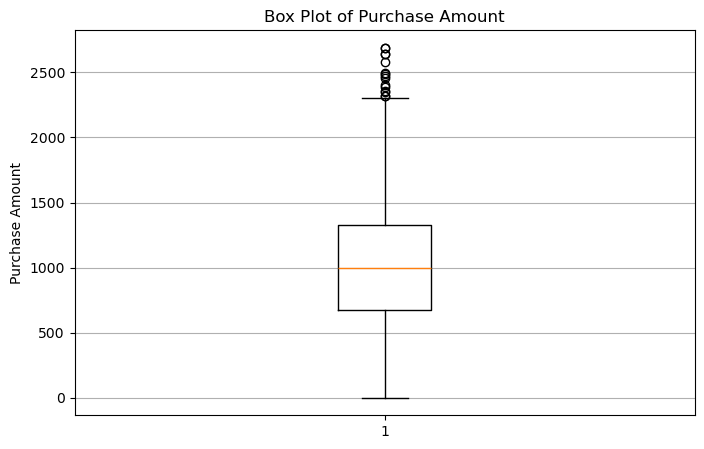


Conclusion:
There are 15 outliers in PurchaseAmount using the IQR method.


QUESTION 3: SKEWNESS AND KURTOSIS
Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705

Interpretation:
PurchaseAmount is positively/right skewed
The distribution is platykurtic


QUESTION 4: MALE VS FEMALE SPENDING
Number of Male customers: 2386
Number of Female customers: 2370

Male Mean: 1019.1766093880973
Female Mean: 987.8720464135021

t-statistic: 2.234798912073049
p-value: 0.025476849797238143

Hypotheses:
H0: There is no significant difference in spending.
H1: There is a significant difference in spending.

Decision: Reject H0
Conclusion: There is a statistically significant difference in spending between male and female customers.


QUESTION 5: PRODUCT CATEGORY VS CHURN

Contingency Table:
Churn             No  Yes
ProductCategory          
Electronics      785  541
Fashion          839  607
Grocery          855  604

Chi-square statistic: 0.3960436652673918
Degrees of freedom: 2
p-value: 0.820

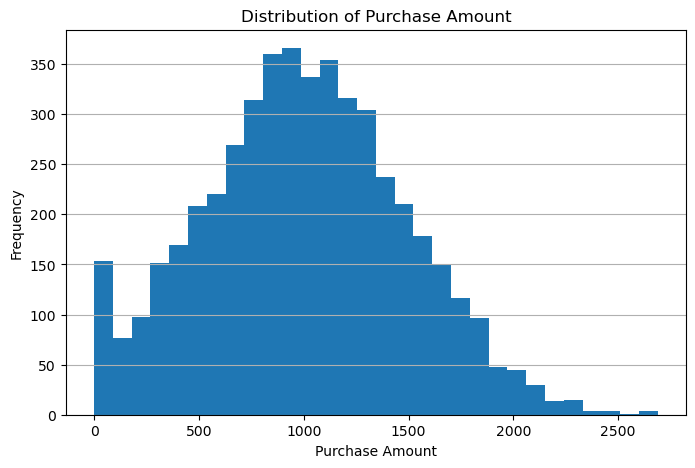



QUESTION 9: CENTRAL LIMIT THEOREM
Number of samples: 1000
Sample size: 30
Mean of sampling distribution: 1009.7798423333334
Standard deviation of sampling distribution: 86.9928504534656


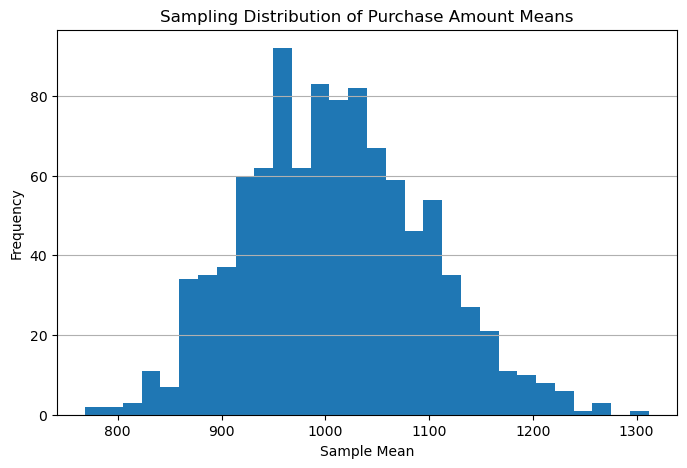


Interpretation:
The Central Limit Theorem states that the distribution of sample means becomes approximately normal when sufficiently large random samples are repeatedly taken.
Therefore, the sample mean can be used to make statistical inferences about the population mean.


QUESTION 10: 95% CONFIDENCE INTERVAL
Sample size: 4850
Sample Mean: 1003.9506701030928
Sample Standard Deviation: 482.11312193311596
Standard Error: 6.922740985370979
t-critical: 1.9604533335640806
Margin of Error: 13.571710642171222

95% Confidence Interval:
Lower Limit: 990.3789594609216
Upper Limit: 1017.522380745264

Conclusion:
We are 95% confident that the true population mean PurchaseAmount lies between 990.38 and 1017.52.


STATISTICS PROJECT COMPLETED SUCCESSFULLY


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    shapiro,
    t
)

df = pd.read_csv("customer_behavior.csv")

print("=" * 70)
print("STATISTICS PROJECT")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

df["PurchaseAmount"] = pd.to_numeric(
    df["PurchaseAmount"],
    errors="coerce"
)

purchase_data = df["PurchaseAmount"].dropna()

print("\nNumber of valid PurchaseAmount values:",
      len(purchase_data))

#1. What is the average, median, and mode of PurchaseAmount?

print("\n")
print("=" * 70)
print("QUESTION 1: AVERAGE, MEDIAN AND MODE")
print("=" * 70)

mean_purchase = purchase_data.mean()
median_purchase = purchase_data.median()
mode_purchase = purchase_data.mode()

print("Average / Mean:", mean_purchase)
print("Median:", median_purchase)
print("Mode:", mode_purchase.tolist())

print("\nInterpretation:")
print(f"The average PurchaseAmount is {mean_purchase:.2f}.")
print(f"The median PurchaseAmount is {median_purchase:.2f}.")
print(f"The mode of PurchaseAmount is {mode_purchase.tolist()}.")

#2. Are there any outliers in the PurchaseAmount data?

print("\n")
print("=" * 70)
print("QUESTION 2: OUTLIER ANALYSIS")
print("=" * 70)

Q1 = purchase_data.quantile(0.25)
Q3 = purchase_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = purchase_data[
    (purchase_data < lower_bound) |
    (purchase_data > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))

print("\nOutlier Values:")
print(outliers.tolist())


# BOX PLOT 

plt.figure(figsize=(8, 5))

plt.boxplot(
    purchase_data,
    vert=True
)

plt.title("Box Plot of Purchase Amount")
plt.ylabel("Purchase Amount")
plt.grid(axis="y")

plt.show()


if len(outliers) > 0:
    print("\nConclusion:")
    print(
        f"There are {len(outliers)} outliers in PurchaseAmount "
        "using the IQR method."
    )
else:
    print("\nConclusion:")
    print("There are no outliers in PurchaseAmount.")

#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

print("\n")
print("=" * 70)
print("QUESTION 3: SKEWNESS AND KURTOSIS")
print("=" * 70)

skewness = purchase_data.skew()
kurtosis = purchase_data.kurt()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

if skewness > 0:
    skew_result = "positively/right skewed"
elif skewness < 0:
    skew_result = "negatively/left skewed"
else:
    skew_result = "approximately symmetric"

if kurtosis > 0:
    kurtosis_result = "leptokurtic"
elif kurtosis < 0:
    kurtosis_result = "platykurtic"
else:
    kurtosis_result = "mesokurtic"

print("\nInterpretation:")
print("PurchaseAmount is", skew_result)
print("The distribution is", kurtosis_result)

#4. Is there a significant difference in spending between male and female customers?

print("\n")
print("=" * 70)
print("QUESTION 4: MALE VS FEMALE SPENDING")
print("=" * 70)

gender_data = df.dropna(
    subset=["Gender", "PurchaseAmount"]
).copy()

male = gender_data[
    gender_data["Gender"].astype(str).str.strip().str.lower() == "male"
]["PurchaseAmount"]

female = gender_data[
    gender_data["Gender"].astype(str).str.strip().str.lower() == "female"
]["PurchaseAmount"]

print("Number of Male customers:", len(male))
print("Number of Female customers:", len(female))

print("\nMale Mean:", male.mean())
print("Female Mean:", female.mean())

t_statistic, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print("\nt-statistic:", t_statistic)
print("p-value:", p_value)

print("\nHypotheses:")
print("H0: There is no significant difference in spending.")
print("H1: There is a significant difference in spending.")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: There is a statistically significant "
        "difference in spending between male and female customers."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "Conclusion: There is no statistically significant "
        "difference in spending between male and female customers."
    )

#5. Is there a relationship between ProductCategory and customer churn?

print("\n")
print("=" * 70)
print("QUESTION 5: PRODUCT CATEGORY VS CHURN")
print("=" * 70)

churn_data = df.dropna(
    subset=["ProductCategory", "Churn"]
)

contingency_table = pd.crosstab(
    churn_data["ProductCategory"],
    churn_data["Churn"]
)

print("\nContingency Table:")
print(contingency_table)

chi2_statistic, chi_p_value, degrees_freedom, expected = (
    chi2_contingency(contingency_table)
)

print("\nChi-square statistic:", chi2_statistic)
print("Degrees of freedom:", degrees_freedom)
print("p-value:", chi_p_value)

print("\nHypotheses:")
print("H0: ProductCategory and Churn are independent.")
print("H1: ProductCategory and Churn are related.")

if chi_p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: There is a significant relationship "
        "between ProductCategory and Churn."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "Conclusion: There is no significant relationship "
        "between ProductCategory and Churn."
    )

#6. Does PurchaseAmount vary significantly across different regions?

print("\n")
print("=" * 70)
print("QUESTION 6: PURCHASE AMOUNT ACROSS REGIONS")
print("=" * 70)

region_data = df.dropna(
    subset=["Region", "PurchaseAmount"]
)

region_means = region_data.groupby(
    "Region"
)["PurchaseAmount"].mean()

print("\nAverage PurchaseAmount by Region:")
print(region_means)

region_groups = []

for region, group in region_data.groupby("Region"):
    region_groups.append(
        group["PurchaseAmount"].values
    )

f_statistic, anova_p_value = f_oneway(
    *region_groups
)

print("\nF-statistic:", f_statistic)
print("p-value:", anova_p_value)

print("\nHypotheses:")
print("H0: Mean PurchaseAmount is the same across all regions.")
print("H1: At least one region has a different mean.")

if anova_p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: PurchaseAmount varies significantly "
        "across different regions."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "Conclusion: There is no significant difference "
        "in PurchaseAmount across different regions."
    )


#7. Which email campaign (A or B) performed better in terms of average PurchaseAmount?

print("\n")
print("=" * 70)
print("QUESTION 7: CAMPAIGN A VS CAMPAIGN B")
print("=" * 70)

campaign_data = df.dropna(
    subset=["CampaignGroup", "PurchaseAmount"]
).copy()

campaign_means = campaign_data.groupby(
    "CampaignGroup"
)["PurchaseAmount"].mean()

print("\nAverage PurchaseAmount by Campaign:")
print(campaign_means)

campaign_A = campaign_data[
    campaign_data["CampaignGroup"]
    .astype(str)
    .str.strip()
    .str.upper() == "A"
]["PurchaseAmount"]

campaign_B = campaign_data[
    campaign_data["CampaignGroup"]
    .astype(str)
    .str.strip()
    .str.upper() == "B"
]["PurchaseAmount"]

mean_A = campaign_A.mean()
mean_B = campaign_B.mean()

print("\nCampaign A Mean:", mean_A)
print("Campaign B Mean:", mean_B)

if mean_A > mean_B:
    print("\nConclusion:")
    print(
        "Campaign A performed better because it has "
        "a higher average PurchaseAmount."
    )

elif mean_B > mean_A:
    print("\nConclusion:")
    print(
        "Campaign B performed better because it has "
        "a higher average PurchaseAmount."
    )

else:
    print("\nConclusion:")
    print("Both campaigns have the same average PurchaseAmount.")


#8. Can we assume PurchaseAmount follows a normal distribution?

print("\n")
print("=" * 70)
print("QUESTION 8: NORMALITY TEST")
print("=" * 70)

shapiro_statistic, shapiro_p_value = shapiro(
    purchase_data
)

print("Shapiro-Wilk statistic:", shapiro_statistic)
print("p-value:", shapiro_p_value)

print("\nHypotheses:")
print("H0: PurchaseAmount follows a normal distribution.")
print("H1: PurchaseAmount does not follow a normal distribution.")

if shapiro_p_value < alpha:
    print("\nDecision: Reject H0")
    print(
        "Conclusion: PurchaseAmount does not follow "
        "a normal distribution."
    )
else:
    print("\nDecision: Fail to reject H0")
    print(
        "Conclusion: PurchaseAmount can be considered "
        "approximately normally distributed."
    )


# HISTOGRAM 

plt.figure(figsize=(8, 5))

plt.hist(
    purchase_data,
    bins=30
)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.grid(axis="y")

plt.show()


# 9. What insights can we gain by applying the Central Limit Theorem?

print("\n")
print("=" * 70)
print("QUESTION 9: CENTRAL LIMIT THEOREM")
print("=" * 70)

number_of_samples = 1000

sample_size = 30

sample_means = []

for i in range(number_of_samples):

    sample = purchase_data.sample(
        n=sample_size,
        replace=True
    )

    sample_mean = sample.mean()

    sample_means.append(sample_mean)

sample_means = np.array(sample_means)

print("Number of samples:", number_of_samples)
print("Sample size:", sample_size)

print(
    "Mean of sampling distribution:",
    sample_means.mean()
)

print(
    "Standard deviation of sampling distribution:",
    sample_means.std()
)


# CLT HISTOGRAM 

plt.figure(figsize=(8, 5))

plt.hist(
    sample_means,
    bins=30
)

plt.title(
    "Sampling Distribution of Purchase Amount Means"
)

plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.grid(axis="y")

plt.show()


print("\nInterpretation:")
print(
    "The Central Limit Theorem states that the distribution "
    "of sample means becomes approximately normal when "
    "sufficiently large random samples are repeatedly taken."
)

print(
    "Therefore, the sample mean can be used to make "
    "statistical inferences about the population mean."
)


# 10.What is the 95% confidence interval for the average PurchaseAmount?

print("\n")
print("=" * 70)
print("QUESTION 10: 95% CONFIDENCE INTERVAL")
print("=" * 70)

data = purchase_data

n = len(data)

sample_mean = data.mean()

sample_std = data.std()

standard_error = sample_std / np.sqrt(n)

t_critical = t.ppf(
    0.975,
    df=n - 1
)

margin_of_error = (
    t_critical * standard_error
)

lower_CI = sample_mean - margin_of_error
upper_CI = sample_mean + margin_of_error

print("Sample size:", n)
print("Sample Mean:", sample_mean)
print("Sample Standard Deviation:", sample_std)
print("Standard Error:", standard_error)
print("t-critical:", t_critical)
print("Margin of Error:", margin_of_error)

print("\n95% Confidence Interval:")
print("Lower Limit:", lower_CI)
print("Upper Limit:", upper_CI)

print("\nConclusion:")
print(
    f"We are 95% confident that the true population mean "
    f"PurchaseAmount lies between {lower_CI:.2f} and "
    f"{upper_CI:.2f}."
)



print("\n")
print("=" * 70)
print("STATISTICS PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)